Predstavitev dobljenih podatkov

Pri tem sem si pomagala z dokumentacijo na [https//:pandas.pydata.org].

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

Uvoz podatkov iz obeh csv datotek.

In [3]:
podatki_serije = pd.read_csv("shows/shows_community.csv")
podatki_epizode = pd.read_csv("shows/epizode_community.csv")
podatki_serije 

,Naslov,Povprecna_ocena_epizode,Stevilo_epizod,Stevilo_ocen_epizod,Stevilo_ocen_sezone,Povprecna_ocena_sezone,Minimalna_ocena,Maksimalna_ocena,Pozicija,ID,Prva_epizoda,Najnovejša_epizoda,Povprecna_dolzina_epizode,Stevilo_sezon,Leta
0,Breaking Bad,8.94,62,4525285,2646745.0,9.5,7.9,9.8,1,1396,2008-01-20,2013-09-29,48.31,5,5
1,Attack on Titan,9.12,89,4295339,732249.0,9.1,8.1,9.8,2,1429,2013-04-07,2022-04-04,23.99,4,8
2,Game of Thrones,8.74,73,5928154,2638292.0,9.2,4.0,9.9,3,1399,2011-04-17,2019-05-19,57.97,8,8
3,The Sopranos,8.61,86,921490,587404.0,9.2,7.7,9.7,4,1398,1999-01-10,2007-06-10,54.14,6,8
4,Avatar: The Last Airbender,8.60,61,531074,448701.0,9.3,6.8,9.9,5,246,2005-02-21,2008-07-19,24.66,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242,Hell on Wheels,8.22,57,43040,60052.0,8.3,7.3,8.9,246,1401,2011-11-06,2015-08-08,28.04,5,3
243,Derry Girls,8.19,19,31783,78646.0,8.5,7.6,9.1,247,76148,2018-01-04,2022-05-18,25.47,3,4
244,Justice League,8.05,52,55087,57533.0,8.5,7.3,9.3,248,1618,2001-11-17,2004-05-29,24.96,2,2
245,Phineas and Ferb,8.15,150,60809,68584.0,8.1,6.7,9.4,249,1877,2007-08-17,2026-01-16,13.27,5,18


In [6]:
dolzina_snemanja = pd.to_datetime(podatki_serije["Najnovejša_epizoda"]) - pd.to_datetime(podatki_serije["Prva_epizoda"])
ocena_epizode = podatki_epizode.groupby("id")["vote_average"].mean().reset_index()



0     2079 days
1     3284 days
2     2954 days
3     3073 days
4     1244 days
         ...   
242   1371 days
243   1595 days
244    924 days
245   6727 days
246    644 days
Length: 247, dtype: timedelta64[us]


In [7]:
podatki_epizode 

,vote_average,community_count,episode_number,season_number,air_date,runtime
0,9.0,12437,1,1,2008-01-20,59
1,8.7,11907,2,1,2008-01-27,49
2,8.8,11764,3,1,2008-02-10,49
3,8.5,11650,4,1,2008-02-17,49
4,8.3,11558,5,1,2008-02-24,49
...,...,...,...,...,...,...
22054,8.4,7,6,2,2009-02-22,27
22055,8.3,7,7,2,2009-03-01,28
22056,8.1,7,8,2,2009-03-08,25
22057,8.1,7,9,2,2009-03-15,27


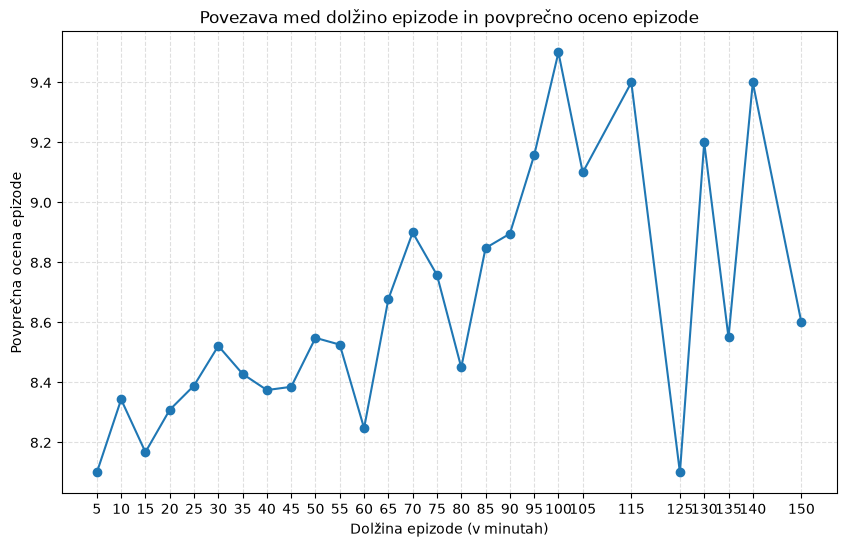

In [42]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .mean()
    .sort_index()
)

intervali = intervali.dropna()

plt.figure(figsize=(10, 6))
plt.title("Povezava med dolžino epizode in povprečno oceno epizode")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Povprečna ocena epizode")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.grid(True, linestyle="--", alpha=0.4)


Graf, ki prikazuje število epizod za določeno dolžino epizode. 

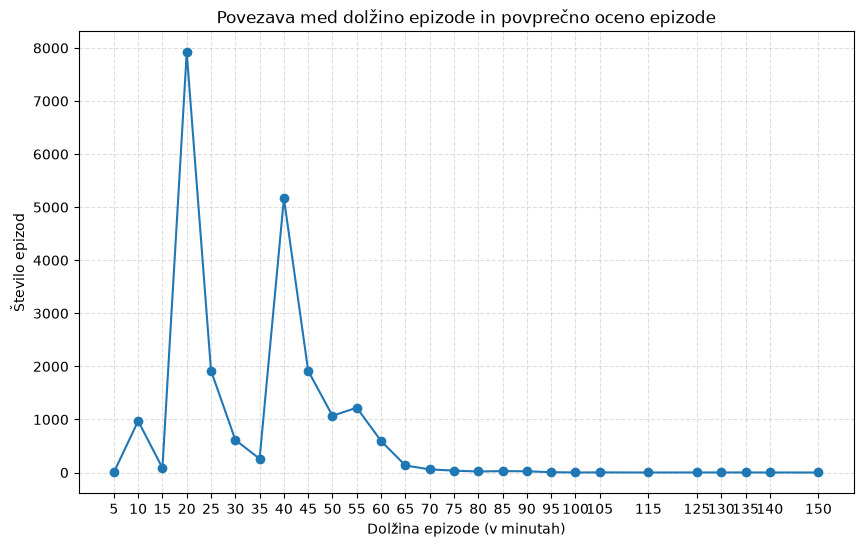

In [43]:
podatki_epizode["bins_dolzina"] = (podatki_epizode["runtime"] // 5) * 5

intervali = (
    podatki_epizode.groupby("bins_dolzina")["vote_average"]
    .count()
    .sort_index()
)

intervali = intervali.dropna()

plt.figure(figsize=(10, 6))
plt.title("Povezava med dolžino epizode in povprečno oceno epizode")
plt.xlabel("Dolžina epizode (v minutah)")
plt.ylabel("Število epizod")
plt.plot(intervali.index, intervali.values, marker="o")
plt.xticks(intervali.index)
plt.grid(True, linestyle="--", alpha=0.4)


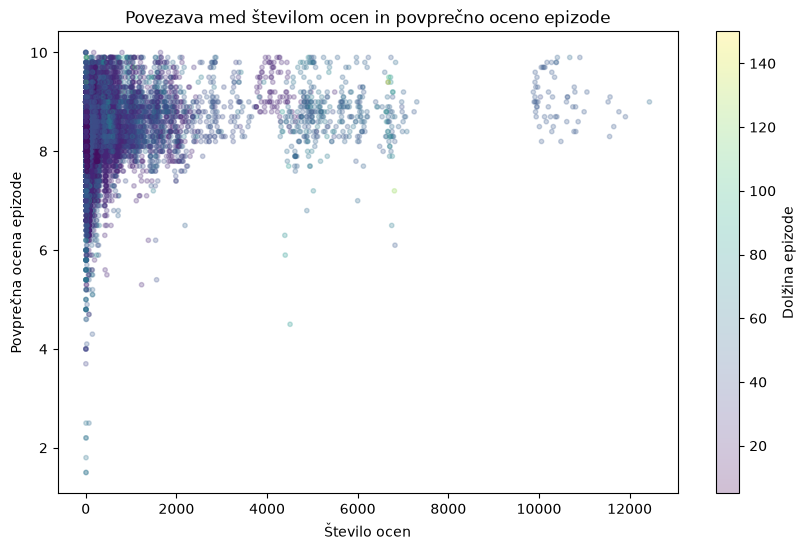

In [53]:
stevilo_ocen = podatki_epizode["community_count"]
povprecna_ocena = podatki_epizode["vote_average"]

plt.figure(figsize=(10, 6))
scatter = plt.scatter(stevilo_ocen, povprecna_ocena, s=10, c=podatki_epizode["bins_dolzina"], alpha=0.25)
plt.title("Povezava med številom ocen in povprečno oceno epizode")
plt.xlabel("Število ocen")  
plt.ylabel("Povprečna ocena epizode")
plt.colorbar(scatter, label="Dolžina epizode")